## RFM Customer Segmentation Analysis

Objective
Segment customers into actionable personas using RFM (Recency, Frequency, Monetary) analysis.
This customer lifecycle framework is widely used in CRM and lifecycle marketing platforms such as Klaviyo, Salesforce Marketing Cloud, and HubSpot.

1. calculate RFM metrics at the customer level
2. score each metric on a 1–5 scale
3. assign customer segments using named personas
4. profile segments and visualise behavioural patterns
5. translate insights into marketing action

Libraries Imported

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path
from datetime import datetime, date

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded ✓')

Libraries loaded ✓


1. Load Clean Data

In [43]:
from pathlib import Path
# Set the base directory to the current working directory
base_dir = Path.cwd().parent
file_path = base_dir.parent / "data" / "cleaned_online_retail_data.csv"
print(f'Loading {file_path} ...')
df = pd.read_csv(file_path, encoding='unicode_escape')
df.head(5)



Loading /Users/umaobbani/Downloads/Customer Life cycle Analysis/data/cleaned_online_retail_data.csv ...


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalRevenue,InvoiceYearMonth,InvoiceYear,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12,2009,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12,2009,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12,2009,Tuesday,7


2. Calculate RFM Metrics

RFM stands for:

1. Recency (R) — How many days since the customer last purchased? Lower = better.
2. Frequency (F) — How many unique orders has the customer placed? Higher = better.
3. Monetary (M) — How much total revenue has the customer generated? Higher = better.
We calculate these at customer level — one row per customer.

In [44]:
# Remove invalid negative sales values before calculating RFM
df = df[df['TotalRevenue'] >= 0].copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Current date
current_date = pd.Timestamp.today().normalize()

# RFM
rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (current_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalRevenue', 'sum')
).reset_index()

# Round monetary value
rfm['Monetary'] = rfm['Monetary'].round(2)

print(f'\nRFM table shape: {rfm.shape}')

print(f'\nRFM Summary Statistics:')
print(
    rfm[['Recency', 'Frequency', 'Monetary']]
    .describe()
    .round(2)
)




RFM table shape: (5881, 4)

RFM Summary Statistics:
       Recency  Frequency   Monetary
count  5881.00    5881.00    5881.00
mean   5591.99       6.29    2954.40
std     209.49      13.01   14437.32
min    5391.00       1.00       0.00
25%    5416.00       1.00     341.90
50%    5486.00       3.00     865.60
75%    5770.00       7.00    2247.72
max    6129.00     398.00  580987.04


In [48]:
rfm.head(10)

,Customer ID,Recency,Frequency,Monetary
0,12346.0,5715,17,-51.74
1,12347.0,5392,8,4921.53
2,12348.0,5465,5,2019.40
3,12349.0,5408,5,4404.54
4,12350.0,5700,1,334.40
5,12351.0,5765,1,300.93
6,12352.0,5426,13,1889.21
7,12353.0,5594,2,406.76
8,12354.0,5622,1,1079.40
9,12355.0,5604,2,947.61


3. RFM Scoring (1–5)
We convert the raw RFM values into scores from 1 to 5 using quintiles (equal-sized buckets).

    1. Recency: Score 5 = bought most recently (lowest recency days). Note: reversed scale.
    2. Frequency: Score 5 = ordered most often.
    3. Monetary: Score 5 = spent the most.
    This normalises all three dimensions onto the same scale for fair comparison.

In [45]:
# ── Score each dimension 1–5 using pd.qcut (quantile-based binning) ────────────

# Recency: LOWER days = BETTER = higher score (so we reverse with labels[::-1])
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1], duplicates='drop').astype(int)

# Frequency: HIGHER orders = BETTER = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)

# Monetary: HIGHER spend = BETTER = higher score
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

# ── Composite RFM Score (simple average) ──────────────────────────────────────
rfm['RFM_Score'] = (rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']) / 3
rfm['RFM_Score'] = rfm['RFM_Score'].round(2)

# ── String label for easy reading e.g. "5-4-3" ───────────────────────────────
rfm['RFM_Label'] = rfm['R_Score'].astype(str) + '-' + rfm['F_Score'].astype(str) + '-' + rfm['M_Score'].astype(str)

print('RFM scoring complete ✓')
print(rfm[['Customer ID','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Score']].head(10))

RFM scoring complete ✓
   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0      12346.0     5716         12  77556.46        2        5        5   
1      12347.0     5393          8   4921.53        5        4        5   
2      12348.0     5466          5   2019.40        3        4        4   
3      12349.0     5409          4   4428.69        5        3        5   
4      12350.0     5701          1    334.40        2        1        2   
5      12351.0     5766          1    300.93        2        1        2   
6      12352.0     5427         10   2849.84        4        5        4   
7      12353.0     5595          2    406.76        2        2        2   
8      12354.0     5623          1   1079.40        2        1        3   
9      12355.0     5605          2    947.61        2        2        3   

   RFM_Score  
0       4.00  
1       4.67  
2       3.67  
3       4.33  
4       1.67  
5       1.67  
6       4.33  
7       2.00  
8       2.00  
9

4. Customer Segmentation
    Using R and F scores (the two strongest behavioural signals), we assign each customer to a named segment.
    These segments map directly to Klaviyo lifecycle flows and Google Ads audience lists.

In [46]:
def assign_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyal'
    elif r == 1 and f >= 4:
        return 'At Risk'
    elif r == 2 and f >= 3:
        return 'Need Attention'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'New Customers'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# ── Segment summary ───────────────────────────────────────────────────────────
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count = ('Customer ID', 'count'),
    Avg_Recency    = ('Recency',    'mean'),
    Avg_Frequency  = ('Frequency',  'mean'),
    Avg_Monetary   = ('Monetary',   'mean'),
    Total_Revenue  = ('Monetary',   'sum')
).round(2).reset_index()

segment_summary['Revenue_%'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100).round(1)
segment_summary['Customer_%'] = (segment_summary['Customer_Count'] / segment_summary['Customer_Count'].sum() * 100).round(1)

print('=== Segment Summary ===')
print(segment_summary.sort_values('Total_Revenue', ascending=False).to_string(index=False))


=== Segment Summary ===
        Segment  Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_%  Customer_%
      Champions            1476      5410.69          15.68       8131.02    12001386.39       69.1        25.1
Loyal Customers            1231      5469.37           5.43       2060.54     2536528.60       14.6        20.9
 Need Attention             550      5694.71           5.21       2058.35     1132093.50        6.5         9.4
           Lost            1524      5850.28           1.25        429.06      653884.67        3.8        25.9
Potential Loyal             829      5455.36           1.41        719.72      596645.47        3.4        14.1
        At Risk              88      5884.53           7.49       3000.59      264052.31        1.5         1.5
  New Customers             183      5897.69           2.93       1039.42      190213.31        1.1         3.1


5. Visualisations

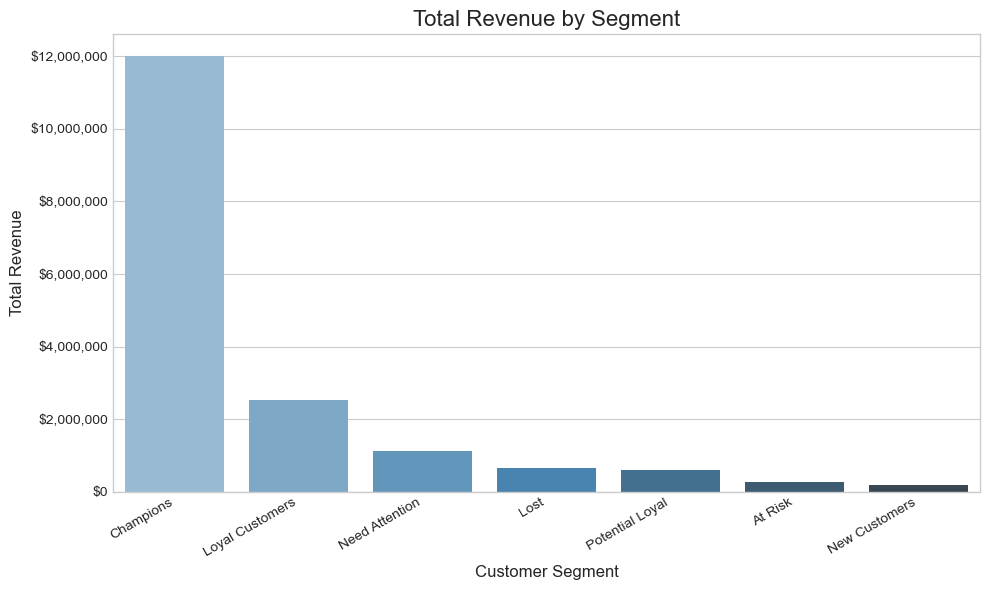

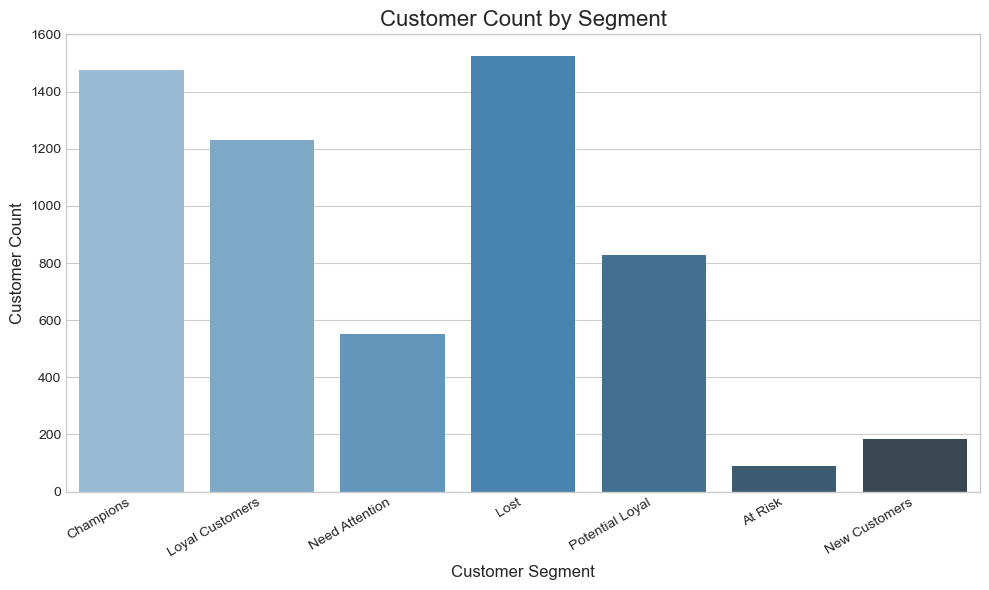

In [47]:
seg = segment_summary.sort_values('Total_Revenue', ascending=False)

# Total revenue by segment
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=seg, x='Segment', y='Total_Revenue', palette='Blues_d', ax=ax)
ax.set_title('Total Revenue by Segment', fontsize=16)
ax.set_xlabel('Customer Segment', fontsize=12)
ax.set_ylabel('Total Revenue', fontsize=12)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Customer count by segment
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=seg, x='Segment', y='Customer_Count', palette='Blues_d', ax=ax)
ax.set_title('Customer Count by Segment', fontsize=16)
ax.set_xlabel('Customer Segment', fontsize=12)
ax.set_ylabel('Customer Count', fontsize=12)
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

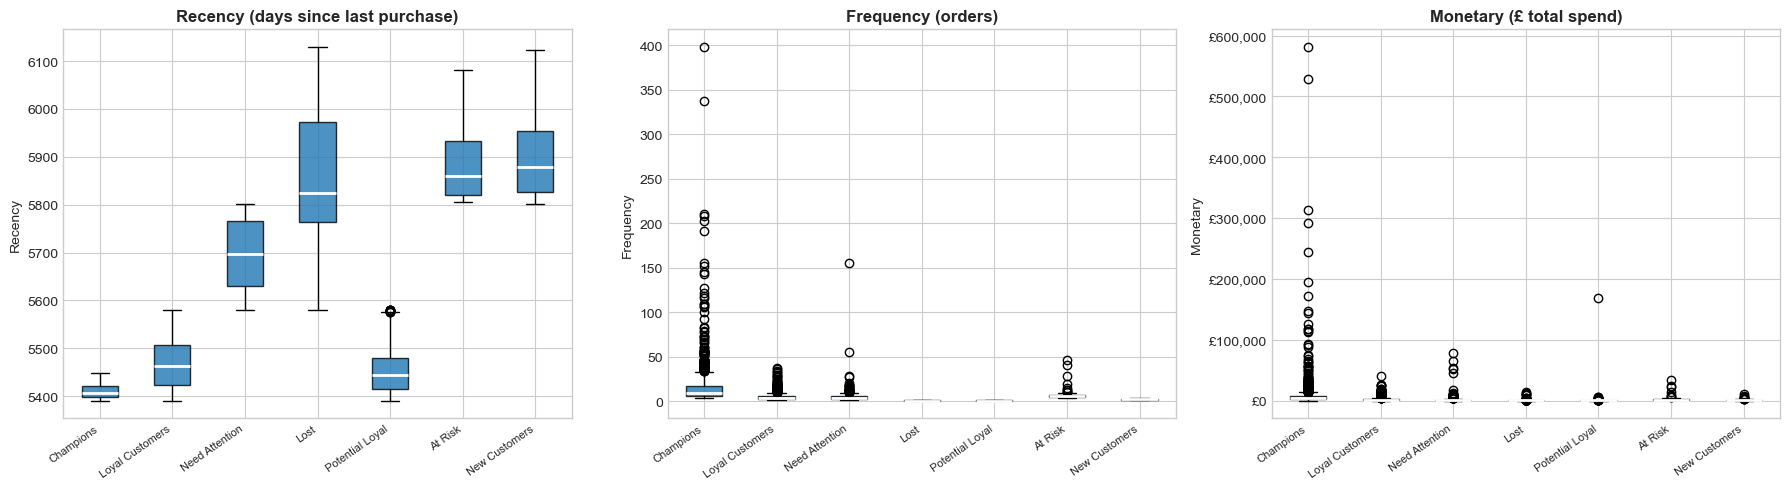

In [48]:
# RFM distribution by segment (boxplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['Recency', 'Frequency', 'Monetary']
titles = ['Recency (days since last purchase)', 'Frequency (orders)', 'Monetary (£ total spend)']
seg_order = seg['Segment'].tolist()

for ax, metric, title in zip(axes, metrics, titles):
    data_by_seg = [rfm[rfm['Segment'] == s][metric].values for s in seg_order]
    bp = ax.boxplot(
        data_by_seg, patch_artist=True, vert=True, widths=0.5,
        medianprops=dict(color='white', linewidth=2)
    )
    for patch in bp['boxes']:
        patch.set_alpha(0.8)
    ax.set_xticklabels(seg_order, rotation=35, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    if metric == 'Monetary':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))



plt.tight_layout()
plt.show()  

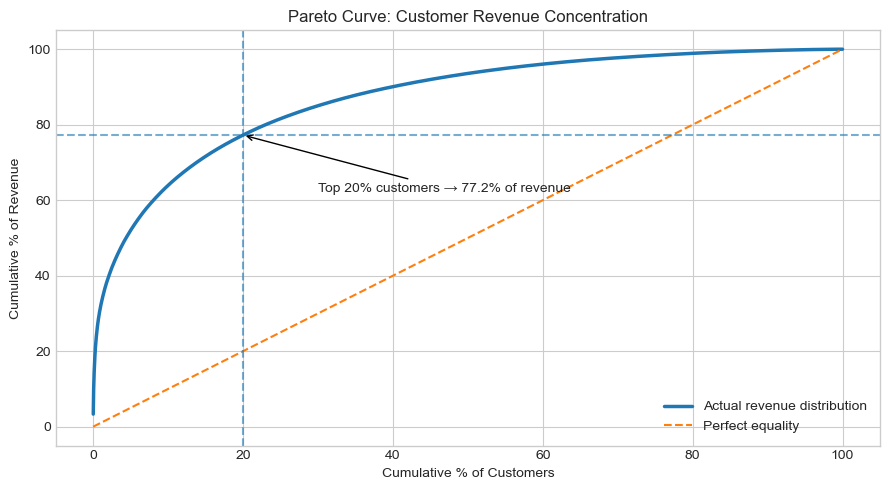

Top 20% of customers generate 77.2% of total revenue.
This is the business case for differentiated CRM strategy.


In [49]:
# 5.5 Pareto Analysis

# Sort customers from highest to lowest spend
rfm_sorted = rfm.sort_values('Monetary', ascending=False).reset_index(drop=True)

# Calculate cumulative revenue and customer percentages
rfm_sorted['cum_revenue_pct'] = (
    rfm_sorted['Monetary'].cumsum()
    / rfm_sorted['Monetary'].sum()
    * 100
)

rfm_sorted['cum_customer_pct'] = (
    (rfm_sorted.index + 1)
    / len(rfm_sorted)
    * 100
)

# Find revenue generated by top 20% of customers
idx_20 = (rfm_sorted['cum_customer_pct'] <= 20).sum() - 1
rev_at_20 = rfm_sorted.loc[idx_20, 'cum_revenue_pct']

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    rfm_sorted['cum_customer_pct'],
    rfm_sorted['cum_revenue_pct'],
    linewidth=2.5,
    label='Actual revenue distribution'
)

# Perfect equality line
ax.plot(
    [0, 100],
    [0, 100],
    '--',
    label='Perfect equality'
)

# Mark 20% customers
ax.axvline(20, linestyle='--', alpha=0.6)
ax.axhline(rev_at_20, linestyle='--', alpha=0.6)

ax.annotate(
    f'Top 20% customers → {rev_at_20:.1f}% of revenue',
    xy=(20, rev_at_20),
    xytext=(30, rev_at_20 - 15),
    arrowprops=dict(arrowstyle='->')
)

ax.set_xlabel('Cumulative % of Customers')
ax.set_ylabel('Cumulative % of Revenue')
ax.set_title('Pareto Curve: Customer Revenue Concentration')

ax.legend()

plt.tight_layout()
plt.show()

print(
    f'Top 20% of customers generate {rev_at_20:.1f}% of total revenue.'
)
print("This is the business case for differentiated CRM strategy.")

6. Segment Profiles & Marketing Action Map

In [50]:
# ── Print key numbers to populate strategy doc ────────────────────────────────
print('=== KEY NUMBERS FOR STRATEGY RECOMMENDATIONS ===')
for _, row in segment_summary.sort_values('Total_Revenue', ascending=False).iterrows():
    print(f"""
Segment        : {row['Segment']}
  Customers    : {int(row['Customer_Count']):,} ({row['Customer_%']}% of base)
  Revenue      : £{row['Total_Revenue']:,.0f} ({row['Revenue_%']}% of total)
  Avg Recency  : {row['Avg_Recency']:.0f} days
  Avg Orders   : {row['Avg_Frequency']:.1f}
  Avg Spend    : £{row['Avg_Monetary']:,.0f}
""")

=== KEY NUMBERS FOR STRATEGY RECOMMENDATIONS ===

Segment        : Champions
  Customers    : 1,476 (25.1% of base)
  Revenue      : £12,001,386 (69.1% of total)
  Avg Recency  : 5411 days
  Avg Orders   : 15.7
  Avg Spend    : £8,131


Segment        : Loyal Customers
  Customers    : 1,231 (20.9% of base)
  Revenue      : £2,536,529 (14.6% of total)
  Avg Recency  : 5469 days
  Avg Orders   : 5.4
  Avg Spend    : £2,061


Segment        : Need Attention
  Customers    : 550 (9.4% of base)
  Revenue      : £1,132,094 (6.5% of total)
  Avg Recency  : 5695 days
  Avg Orders   : 5.2
  Avg Spend    : £2,058


Segment        : Lost
  Customers    : 1,524 (25.9% of base)
  Revenue      : £653,885 (3.8% of total)
  Avg Recency  : 5850 days
  Avg Orders   : 1.2
  Avg Spend    : £429


Segment        : Potential Loyal
  Customers    : 829 (14.1% of base)
  Revenue      : £596,645 (3.4% of total)
  Avg Recency  : 5455 days
  Avg Orders   : 1.4
  Avg Spend    : £720


Segment        : At Risk
  

In [51]:
# save file to the project-level data folder
from pathlib import Path

project_root = Path.cwd().resolve().parent
output_dir = project_root / 'data'
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / 'rfm_segments.csv'
rfm.to_csv(output_path, index=False)

print(f'✓ RFM segments saved → {output_path}')
print(f'  Shape  : {rfm.shape}')
print(f'  Columns: {list(rfm.columns)}')

print(f'\n✓ Segments in file: {rfm["Segment"].value_counts().to_dict()}')

✓ RFM segments saved → /Users/umaobbani/Downloads/Customer Life cycle Analysis/RFM Customer Segment Analysis/data/rfm_segments.csv
  Shape  : (5881, 10)
  Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Label', 'Segment']

✓ Segments in file: {'Lost': 1524, 'Champions': 1476, 'Loyal Customers': 1231, 'Potential Loyal': 829, 'Need Attention': 550, 'New Customers': 183, 'At Risk': 88}
